In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
import os

os.chdir(r'C:\Users\aruna\Desktop\Work\MLDAY1')

df=pd.read_csv('Titanic-Cleaned.csv')
X=df.drop(columns=['Survived'])
y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))



Accuracy: 0.7877
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [2]:
print(f"Train accuracy: {accuracy_score(y_train, model.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_pred):.4f}")

Train accuracy: 0.9789
Test accuracy:  0.7877


In [3]:
model_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
model_limited.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model_limited.predict(X_train))
test_acc = accuracy_score(y_test, model_limited.predict(X_test))

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

Train accuracy: 0.8343
Test accuracy:  0.7989


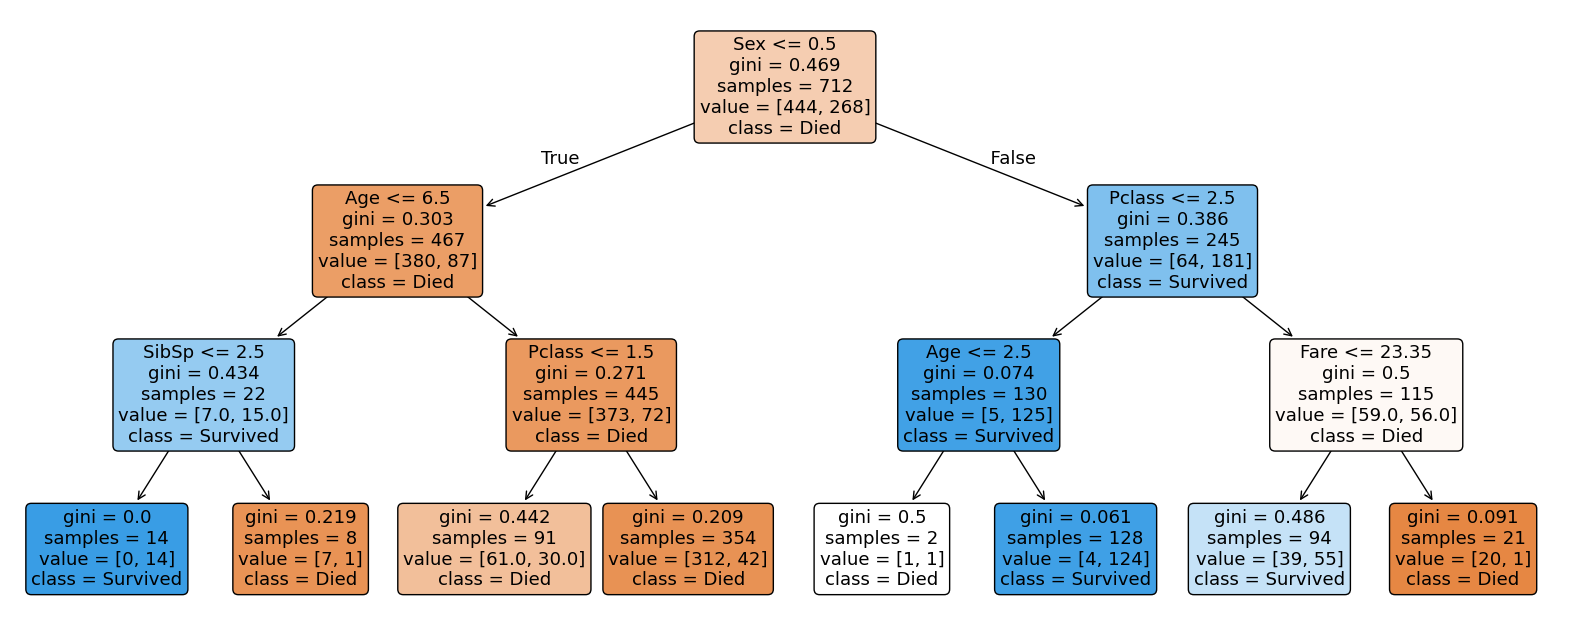

In [4]:
plt.figure(figsize=(20, 8))
plot_tree(model_limited, 
          feature_names=X.columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True)
plt.show()